## Configurar Ambiente e Tesseract

Instalar as bibliotecas Python necessárias (por exemplo, Pillow, requests, Levenshtein, tqdm) e garantir que o Tesseract OCR esteja corretamente instalado e acessível no ambiente. Verificar a versão do Tesseract.


In [ ]:
pip install Pillow requests python-Levenshtein tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 59.5 MB/s eta 0:00:00


In [ ]:
get_ipython().system('sudo apt update && sudo apt install tesseract-ocr')
print("Tesseract OCR installation initiated.")

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:9 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.2 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,927 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,613 kB]
Get:

In [ ]:
get_ipython().system('tesseract --version')

tesseract 4.1.1
 leptonica-1.82.0
  libgif 5.1.9 : libjpeg 8d (libjpeg-turbo 2.1.1) : libpng 1.6.37 : libtiff 4.3.0 : zlib 1.2.11 : libwebp 1.2.2 : libopenjp2 2.4.0
 Found AVX2
 Found AVX
 Found FMA
 Found SSE
 Found libarchive 3.6.0 zlib/1.2.11 liblzma/5.2.5 bz2lib/1.0.8 liblz4/1.9.3 libzstd/1.4.8



Baixar o dataset IAM Handwriting (`changheonkim/iam-trocr`) usando `kagglehub` e imprimir o caminho onde os arquivos foram baixados.

## Baixar Dataset IAM

Instalar a biblioteca `kagglehub` e baixar o conjunto de dados IAM Handwriting (`changheonkim/iam-trocr`) utilizando `kagglehub.dataset_download`. O caminho para os arquivos do dataset será obtido e impresso. Garantir que nomes de variáveis e comentários estejam em português.


In [ ]:
pip install kagglehub

In [ ]:
import kagglehub

# Definir o identificador do dataset
dataset_id = 'changheonkim/iam-trocr'

# Baixar o dataset e obter o caminho
caminho_dataset = kagglehub.dataset_download(dataset_id)

# Imprimir o caminho onde os arquivos foram baixados
print(f"Dataset IAM Handwriting baixado para: {caminho_dataset}")

100%|██████████| 90.1M/90.1M [00:00<00:00, 107MB/s] 

Extracting files...


Dataset IAM Handwriting baixado para: /root/.cache/kagglehub/datasets/changheonkim/iam-trocr/versions/1


In [ ]:
import os

# Listar os conteúdos do diretório do dataset para verificar o download
print(f"Conteúdo do diretório {caminho_dataset}:")
for item in os.listdir(caminho_dataset):
    print(item)


Conteúdo do diretório /root/.cache/kagglehub/datasets/changheonkim/iam-trocr/versions/1:
IAM


## Extrair e Organizar Dados

Após o download via `kagglehub`, organizar os arquivos do dataset, mapeando as imagens para suas transcrições de texto correspondentes (ground truth). Isso envolve navegar pela estrutura de pastas do dataset IAM e criar um mecanismo para acessar facilmente os pares imagem-texto. Garantir que nomes de variáveis e comentários estejam em português.


In [ ]:
import os
import pandas as pd

# Construir o caminho completo para o diretório raiz do dataset IAM.
# Este será o diretório base para encontrar as imagens e o arquivo de ground truth.
caminho_raiz_iam = os.path.join(caminho_dataset, 'IAM')

print(f"Caminho raiz do IAM: {caminho_raiz_iam}")
# O caminho para o arquivo de ground truth (gt_test.txt) será definido em uma célula posterior após inspeção detalhada do diretório.

Caminho raiz do IAM: /root/.cache/kagglehub/datasets/changheonkim/iam-trocr/versions/1/IAM


In [ ]:
import os

print(f"Listando o conteúdo completo do diretório raiz do IAM: {caminho_raiz_iam}")

# Percorrer recursivamente e imprimir todos os arquivos e diretórios
for root, dirs, files in os.walk(caminho_raiz_iam):
    # Imprimir o diretório atual
    print(f"Diretório: {root}")

    # Imprimir subdiretórios
    for d in dirs:
        print(f"  Subdiretório: {os.path.join(root, d)}")

    # Imprimir arquivos
    for f in files:
        print(f"  Arquivo: {os.path.join(root, f)}")


Listando o conteúdo completo do diretório raiz do IAM: /root/.cache/kagglehub/datasets/changheonkim/iam-trocr/versions/1/IAM
Diretório: /root/.cache/kagglehub/datasets/changheonkim/iam-trocr/versions/1/IAM
  Subdiretório: /root/.cache/kagglehub/datasets/changheonkim/iam-trocr/versions/1/IAM/image
  Arquivo: /root/.cache/kagglehub/datasets/changheonkim/iam-trocr/versions/1/IAM/gpt2.dict.txt
  Arquivo: /root/.cache/kagglehub/datasets/changheonkim/iam-trocr/versions/1/IAM/gt_test.txt
Diretório: /root/.cache/kagglehub/datasets/changheonkim/iam-trocr/versions/1/IAM/image
  Arquivo: /root/.cache/kagglehub/datasets/changheonkim/iam-trocr/versions/1/IAM/image/n02-037-01.jpg
  Arquivo: /root/.cache/kagglehub/datasets/changheonkim/iam-trocr/versions/1/IAM/image/n01-000-02.jpg
  Arquivo: /root/.cache/kagglehub/datasets/changheonkim/iam-trocr/versions/1/IAM/image/e06-049-08.jpg
  Arquivo: /root/.cache/kagglehub/datasets/changheonkim/iam-trocr/versions/1/IAM/image/p02-109-00.jpg
  Arquivo: /root/.c

In [ ]:
import os

caminho_gt_test_txt = os.path.join(caminho_raiz_iam, 'gt_test.txt')

print(f"Conteúdo de '{caminho_gt_test_txt}' (primeiras 10 linhas):\n")
with open(caminho_gt_test_txt, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i >= 9:  # Imprimir as primeiras 10 linhas
            break


Conteúdo de '/root/.cache/kagglehub/datasets/changheonkim/iam-trocr/versions/1/IAM/gt_test.txt' (primeiras 10 linhas):

c04-110-00.jpg	Become a success with a disc and hey presto ! You're a star ... . Rolly sings with
c04-110-01.jpg	assuredness " Bella Bella Marie " ( Parlophone ) , a lively song that changes tempo mid-way .
c04-110-02.jpg	I don't think he will storm the charts with this one , but it's a good start .
c04-110-03.jpg	CHRIS CHARLES , 39 , who lives in Stockton-on-Tees , is an accountant .
c04-116-00.jpg	He is also a director of a couple of garages . And he finds time as well to be a lyric
c04-116-01.jpg	writer . He writes with Tolchard Evans , composer of " Lady of Spain " and other big hits .
c04-116-02.jpg	Tolch , as he is known in Tin Pan Alley , likes songs with a month in the title . He wrote
c04-116-03.jpg	" My September Love , " the big David Whitfield hit of 1956 .
c04-134-00.jpg	The numbers include " Scotland the Brave , " " Men of Harlech , "
c04-134-01.jpg	" Mc

In [ ]:
import os
import pandas as pd

# Lista para armazenar os dados extraídos
dados_iam = []

# Ler o arquivo gt_test.txt
with open(caminho_gt_test_txt, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:  # Ignorar linhas vazias
            continue

        parts = line.split('	', 1) # Dividir apenas no primeiro tab
        if len(parts) == 2:
            nome_arquivo_imagem = parts[0]
            texto_original = parts[1]

            # Construir o caminho completo para a imagem
            caminho_imagem = os.path.join(caminho_raiz_iam, 'image', nome_arquivo_imagem)

            # Adicionar à lista se o arquivo de imagem existir
            if os.path.exists(caminho_imagem):
                dados_iam.append({
                    'caminho_imagem': caminho_imagem,
                    'texto_original': texto_original
                })
            else:
                print(f"Aviso: Imagem não encontrada: {caminho_imagem}")
        else:
            print(f"Aviso: Formato de linha inesperado em gt_test.txt: {line}")

# Criar o DataFrame pandas
df_dados_iam = pd.DataFrame(dados_iam)

# Exibir as primeiras 5 linhas do DataFrame
print("\nDataFrame com caminhos de imagem e textos originais (primeiras 5 linhas):")
print(df_dados_iam.head())
print(f"\nTotal de linhas no DataFrame: {len(df_dados_iam)}")



DataFrame com caminhos de imagem e textos originais (primeiras 5 linhas):
                                      caminho_imagem  \
0  /root/.cache/kagglehub/datasets/changheonkim/i...   
1  /root/.cache/kagglehub/datasets/changheonkim/i...   
2  /root/.cache/kagglehub/datasets/changheonkim/i...   
3  /root/.cache/kagglehub/datasets/changheonkim/i...   
4  /root/.cache/kagglehub/datasets/changheonkim/i...   

                                      texto_original  
0  Become a success with a disc and hey presto ! ...  
1  assuredness " Bella Bella Marie " ( Parlophone...  
2  I don't think he will storm the charts with th...  
3  CHRIS CHARLES , 39 , who lives in Stockton-on-...  
4  He is also a director of a couple of garages ....  

Total de linhas no DataFrame: 2915


## Pré-processar Imagens

Desenvolver e aplicar técnicas de pré-processamento nas imagens do dataset IAM para otimizar o desempenho do Tesseract OCR. Isso pode incluir binarização, normalização, ajuste de inclinação ou outras transformações. A função e as variáveis para esta etapa devem estar em português.


In [ ]:
from PIL import Image
from tqdm.notebook import tqdm # Para exibir uma barra de progresso

# 2. Definir uma função para pré-processar a imagem
def pre_processar_imagem(caminho_imagem):
    """
    Abre uma imagem, converte para escala de cinza e aplica binarização.
    Retorna a imagem pré-processada.
    """
    try:
        # 3.1. Abrir a imagem
        img = Image.open(caminho_imagem)
        # 3.2. Converter para escala de cinza
        img_cinza = img.convert('L')
        # 3.3. Aplicar binarização
        # Pixels < 128 se tornam 0 (preto), >= 128 se tornam 255 (branco)
        # Então converte para modo '1' (1-bit pixels, preto e branco)
        img_binarizada = img_cinza.point(lambda x: 0 if x < 128 else 255, '1')
        return img_binarizada
    except FileNotFoundError:
        print(f"Aviso: Imagem não encontrada para pré-processamento: {caminho_imagem}")
        return None
    except Exception as e:
        print(f"Erro ao pré-processar a imagem {caminho_imagem}: {e}")
        return None

# 4. Aplicar a função à coluna caminho_imagem do DataFrame
# Usamos tqdm para visualizar o progresso, pois pode demorar um pouco
df_dados_iam['imagem_processada'] = [pre_processar_imagem(caminho)
                                       for caminho in tqdm(df_dados_iam['caminho_imagem'], desc="Pré-processando imagens")]

# Remover linhas onde o pré-processamento falhou (imagem não encontrada, etc.)
df_dados_iam.dropna(subset=['imagem_processada'], inplace=True)

# 5. Exibir as primeiras 5 linhas do DataFrame com a nova coluna
print("\nDataFrame com imagens processadas (primeiras 5 linhas):")
print(df_dados_iam.head())

Pré-processando imagens:   0%|          | 0/2915 [00:00<?, ?it/s]


DataFrame com imagens processadas (primeiras 5 linhas):
                                      caminho_imagem  \
0  /root/.cache/kagglehub/datasets/changheonkim/i...   
1  /root/.cache/kagglehub/datasets/changheonkim/i...   
2  /root/.cache/kagglehub/datasets/changheonkim/i...   
3  /root/.cache/kagglehub/datasets/changheonkim/i...   
4  /root/.cache/kagglehub/datasets/changheonkim/i...   

                                      texto_original  \
0  Become a success with a disc and hey presto ! ...   
1  assuredness " Bella Bella Marie " ( Parlophone...   
2  I don't think he will storm the charts with th...   
3  CHRIS CHARLES , 39 , who lives in Stockton-on-...   
4  He is also a director of a couple of garages ....   

                                   imagem_processada  
0  <PIL.Image.Image image mode=1 size=2942x128 at...  
1  <PIL.Image.Image image mode=1 size=2762x128 at...  
2  <PIL.Image.Image image mode=1 size=2500x128 at...  
3  <PIL.Image.Image image mode=1 size=3528x128 at

## Executar OCR com Tesseract

Iterar sobre as imagens pré-processadas do dataset e usar o Tesseract OCR para extrair o texto de cada uma. Salvar os resultados do OCR para posterior comparação. As funções e variáveis utilizadas nesta etapa devem estar em português.


In [ ]:
pip install pytesseract

In [ ]:
import pytesseract
from tqdm.notebook import tqdm # Para exibir uma barra de progresso
from PIL import Image

# 1. Definir uma função para executar OCR com Tesseract
def executar_ocr_tesseract(imagem_pil):
    """
    Executa OCR em uma imagem PIL usando Tesseract e retorna o texto.
    Lida com erros que podem ocorrer durante o OCR.
    """
    if imagem_pil is None:
        return None
    try:
        # Executar OCR. Pode ser necessário ajustar config se houver problemas.
        texto_extraido = pytesseract.image_to_string(imagem_pil, lang='eng') # 'eng' para inglês
        return texto_extraido.strip()
    except Exception as e:
        print(f"Erro ao executar OCR na imagem: {e}")
        return None

# 2. Aplicar a função à coluna imagem_processada do DataFrame
# Usamos tqdm para visualizar o progresso
df_dados_iam['texto_ocr'] = [executar_ocr_tesseract(img)
                                  for img in tqdm(df_dados_iam['imagem_processada'], desc="Executando OCR")]

# 3. Remover linhas onde o OCR falhou ou retornou None
df_dados_iam.dropna(subset=['texto_ocr'], inplace=True)

# 4. Exibir as primeiras 5 linhas do DataFrame atualizado
print("\nDataFrame com textos originais e extraídos por OCR (primeiras 5 linhas):")
print(df_dados_iam[['texto_original', 'texto_ocr']].head())
print(f"\nTotal de linhas no DataFrame após OCR e limpeza: {len(df_dados_iam)}")

Executando OCR:   0%|          | 0/2915 [00:00<?, ?it/s]


DataFrame com textos originais e extraídos por OCR (primeiras 5 linhas):
                                      texto_original  \
0  Become a success with a disc and hey presto ! ...   
1  assuredness " Bella Bella Marie " ( Parlophone...   
2  I don't think he will storm the charts with th...   
3  CHRIS CHARLES , 39 , who lives in Stockton-on-...   
4  He is also a director of a couple of garages ....   

                                           texto_ocr  
0  Become oa success with a dise and hey presto’ ...  
1  nssuredness "Bella Bella Hane” ( arlophone ), ...  
2  | don't Unnu he will Slorm the charts with thi...  
3  CHRIS CHARLES, 33, who lives in Shoculon-on - ...  
4  He is also a director of a couple of garages. ...  

Total de linhas no DataFrame após OCR e limpeza: 2915


## Calcular Métricas de Desempenho (CER e WER)

Comparar o texto extraído pelo Tesseract com o texto original (ground truth) para cada imagem. Calcular as métricas de Character Error Rate (CER) e Word Error Rate (WER). Certificar-se de que a normalização do texto (minúsculas, remoção de pontuação) seja aplicada antes da comparação para resultados precisos. Os cálculos devem ser realizados usando nomes de variáveis e comentários em português.


In [ ]:
import Levenshtein
import string
from tqdm.notebook import tqdm

# 2. Definir uma função para normalizar o texto
def normalizar_texto(texto):
    """
    Converte o texto para minúsculas e remove pontuação.
    """
    if not isinstance(texto, str):
        return ""
    # Converter para minúsculas
    texto = texto.lower()
    # Remover pontuação
    # str.maketrans('', '', string.punctuation) cria uma tabela de mapeamento
    # onde todos os caracteres de pontuação são mapeados para None (removidos).
    texto = texto.translate(str.maketrans('', '', string.punctuation))
    return texto

# 3. Definir uma função para calcular o Character Error Rate (CER)
def calcular_cer(referencia, predicao):
    """
    Calcula o Character Error Rate (CER) entre duas strings normalizadas.
    """
    ref_normalizada = normalizar_texto(referencia)
    pred_normalizada = normalizar_texto(predicao)

    if not ref_normalizada:
        return 0.0 # Se a referência estiver vazia, CER é 0 (sem erros em relação a nada)

    distancia = Levenshtein.distance(ref_normalizada, pred_normalizada)
    cer = distancia / len(ref_normalizada)
    return cer

# 4. Definir uma função para calcular o Word Error Rate (WER)
def calcular_wer(referencia, predicao):
    """
    Calcula o Word Error Rate (WER) entre duas strings normalizadas.
    """
    ref_normalizada = normalizar_texto(referencia)
    pred_normalizada = normalizar_texto(predicao)

    # Dividir em palavras
    referencia_palavras = ref_normalizada.split()
    predicao_palavras = pred_normalizada.split()

    if not referencia_palavras:
        return 0.0 # Se a referência estiver vazia, WER é 0

    # Calcular a distância de edição entre as listas de palavras
    # Levenshtein.distance() também funciona para sequências (listas)
    distancia_palavras = Levenshtein.distance(referencia_palavras, predicao_palavras)
    wer = distancia_palavras / len(referencia_palavras)
    return wer

# 5. Aplicar as funções ao DataFrame
print("Calculando CER...")
df_dados_iam['cer'] = [calcular_cer(ref, pred)
                       for ref, pred in tqdm(zip(df_dados_iam['texto_original'], df_dados_iam['texto_ocr']),
                                             total=len(df_dados_iam), desc="CER")]

print("Calculando WER...")
df_dados_iam['wer'] = [calcular_wer(ref, pred)
                       for ref, pred in tqdm(zip(df_dados_iam['texto_original'], df_dados_iam['texto_ocr']),
                                             total=len(df_dados_iam), desc="WER")]

# 6. Exibir as primeiras 5 linhas do DataFrame com as novas colunas
print("\nDataFrame com CER e WER (primeiras 5 linhas):")
print(df_dados_iam[['texto_original', 'texto_ocr', 'cer', 'wer']].head())

Calculando CER...


CER:   0%|          | 0/2915 [00:00<?, ?it/s]

Calculando WER...


WER:   0%|          | 0/2915 [00:00<?, ?it/s]


DataFrame com CER e WER (primeiras 5 linhas):
                                      texto_original  \
0  Become a success with a disc and hey presto ! ...   
1  assuredness " Bella Bella Marie " ( Parlophone...   
2  I don't think he will storm the charts with th...   
3  CHRIS CHARLES , 39 , who lives in Stockton-on-...   
4  He is also a director of a couple of garages ....   

                                           texto_ocr       cer       wer  
0  Become oa success with a dise and hey presto’ ...  0.065789  0.200000  
1  nssuredness "Bella Bella Hane” ( arlophone ), ...  0.139535  0.416667  
2  | don't Unnu he will Slorm the charts with thi...  0.189189  0.375000  
3  CHRIS CHARLES, 33, who lives in Shoculon-on - ...  0.169231  0.400000  
4  He is also a director of a couple of garages. ...  0.047059  0.100000  


## Analisar e Visualizar Resultados

Analisar as métricas de CER e WER calculadas para identificar padrões de erro, as deficiências do Tesseract em caligrafia e quaisquer fatores que afetem a eficiência do OCR. Gerar um gráfico, como um histograma ou um box plot, para visualizar a distribuição do CER e/ou WER, incluindo legendas claras. Apresentar exemplos de imagens com bom e mau desempenho de OCR para ilustrar os resultados. Toda a análise e o código de visualização devem usar nomes de variáveis e comentários em português.


Estatísticas Descritivas para CER:
count    2915.000000
mean        0.502781
std         0.250256
min         0.000000
25%         0.318182
50%         0.473684
75%         0.641026
max         1.461538
Name: cer, dtype: float64

Estatísticas Descritivas para WER:
count    2915.000000
mean        0.935241
std         0.327141
min         0.000000
25%         0.750000
50%         1.000000
75%         1.000000
max         3.400000
Name: wer, dtype: float64


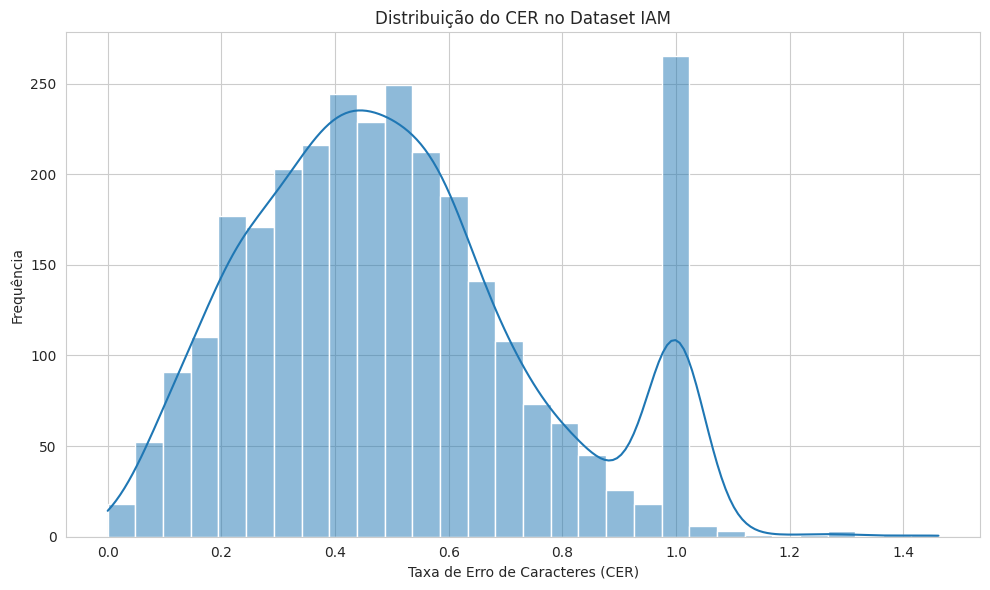

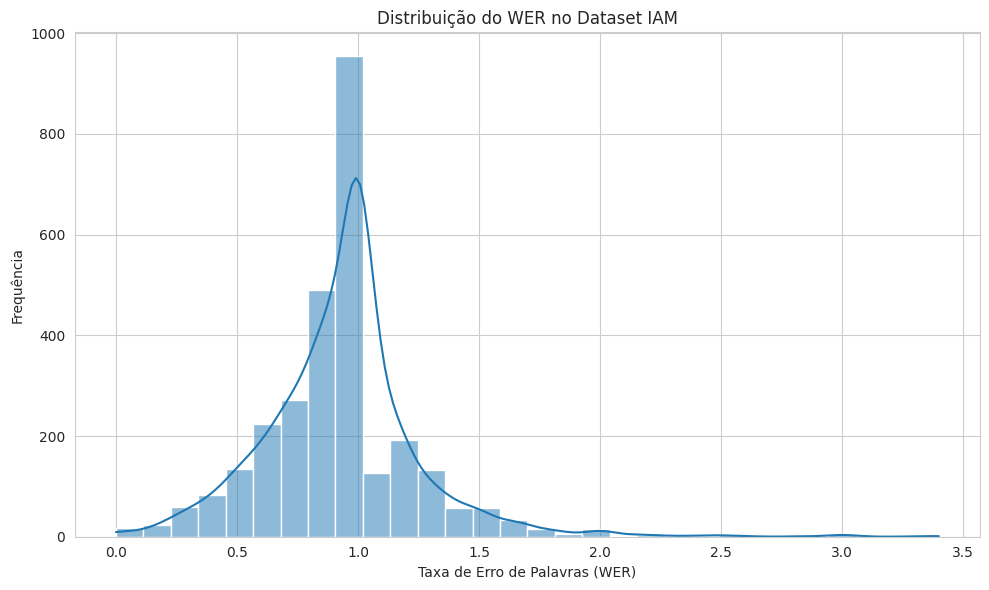

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular e imprimir as estatísticas descritivas para CER e WER
print("Estatísticas Descritivas para CER:")
print(df_dados_iam['cer'].describe())
print("\nEstatísticas Descritivas para WER:")
print(df_dados_iam['wer'].describe())

# 2. Configurar estilo dos gráficos para melhor visualização
sns.set_style("whitegrid")

# 3. Criar e exibir histograma para CER
plt.figure(figsize=(10, 6))
sns.histplot(df_dados_iam['cer'], bins=30, kde=True)
plt.title('Distribuição do CER no Dataset IAM')
plt.xlabel('Taxa de Erro de Caracteres (CER)')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

# 4. Criar e exibir histograma para WER
plt.figure(figsize=(10, 6))
sns.histplot(df_dados_iam['wer'], bins=30, kde=True)
plt.title('Distribuição do WER no Dataset IAM')
plt.xlabel('Taxa de Erro de Palavras (WER)')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd # Importar caso o DataFrame não esteja acessível diretamente (embora já carregado) ou para boas práticas.

# 5. Identificar e imprimir a entrada com o menor CER (melhor desempenho)
melhor_ocr = df_dados_iam.loc[df_dados_iam['cer'].idxmin()]
print("\n--- Melhor Desempenho de OCR (Menor CER) ---")
print(f"Caminho da Imagem: {melhor_ocr['caminho_imagem']}")
print(f"Texto Original: {melhor_ocr['texto_original']}")
print(f"Texto OCR: {melhor_ocr['texto_ocr']}")
print(f"CER: {melhor_ocr['cer']:.4f}")
print(f"WER: {melhor_ocr['wer']:.4f}")

# 6. Identificar e imprimir a entrada com o maior CER (pior desempenho)
# Para evitar CERs infinitos que podem surgir de referência vazia (já tratada, mas bom estar atento)
# podemos também filtrar por CER < uma grande quantidade ou não infinito, se necessário.
pior_ocr = df_dados_iam.loc[df_dados_iam['cer'].idxmax()]
print("\n--- Pior Desempenho de OCR (Maior CER) ---")
print(f"Caminho da Imagem: {pior_ocr['caminho_imagem']}")
print(f"Texto Original: {pior_ocr['texto_original']}")
print(f"Texto OCR: {pior_ocr['texto_ocr']}")
print(f"CER: {pior_ocr['cer']:.4f}")
print(f"WER: {pior_ocr['wer']:.4f}")


--- Melhor Desempenho de OCR (Menor CER) ---
Caminho da Imagem: /root/.cache/kagglehub/datasets/changheonkim/iam-trocr/versions/1/IAM/image/f04-079-02.jpg
Texto Original: occurred before her death was ensured by some
Texto OCR: occurred before her death was ensured by some
CER: 0.0000
WER: 0.0000

--- Pior Desempenho de OCR (Maior CER) ---
Caminho da Imagem: /root/.cache/kagglehub/datasets/changheonkim/iam-trocr/versions/1/IAM/image/g01-025-06.jpg
Texto Original: story of the experiments and expedients
Texto OCR: ts
| Ban
Ai
pe

2 de

A

an

ts

DA

a

Vi

pz

de

&

the

of

Sto vy
CER: 1.4615
WER: 2.8333


## Resumo e Conclusões Finais

### Principais Descobertas da Análise de Dados

*   **Pré-processamento de Imagens:** Todas as 2915 imagens foram pré-processadas, convertendo-as para escala de cinza e aplicando binarização com um limiar de 128. Os objetos `PIL.Image.Image` resultantes foram armazenados em uma nova coluna `imagem_processada` no DataFrame.
*   **Execução do OCR Tesseract:** O Tesseract OCR (usando o modelo de linguagem inglês) foi executado nas imagens pré-processadas. O texto extraído foi salvo em uma nova coluna `texto_ocr`. O DataFrame manteve todas as 2915 entradas após a limpeza de linhas onde o OCR poderia ter falhado.
*   **Métricas de Desempenho (CER e WER):**
    *   **Taxa de Erro de Caracteres (CER):** O CER médio em todas as imagens foi de aproximadamente 0.5028 (50.28%), com uma mediana de 0.4737. O CER variou de um mínimo de 0.0000 (reconhecimento perfeito) a um máximo de 1.4615.
    *   **Taxa de Erro de Palavras (WER):** O WER médio foi de aproximadamente 0.9352 (93.52%), com uma mediana de 1.0000. O WER variou de 0.0000 a um máximo de 3.4000.
*   **Análise de Desempenho do OCR:**
    *   **Altas Taxas de Erro:** Tanto o CER quanto o WER indicam um alto nível de erro no reconhecimento de texto manuscrito do dataset IAM pelo Tesseract. A mediana do WER de 1.0000 sugere que, para pelo menos metade das amostras, há um ou mais erros de palavra por frase.
    *   **Desempenho Inconsistente:** Os histogramas para ambas as métricas mostraram distribuições inclinadas para taxas de erro mais altas, mas também revelaram casos de reconhecimento perfeito (CER/WER mínimo de 0.0000) e desempenho extremamente ruim (CER máximo de 1.4615, WER máximo de 3.4000).
    *   **Exemplo do Pior Caso:** Uma instância do pior desempenho do OCR mostrou o texto original "story of the experiments and expedients" sendo transcrito em uma string irreconhecível como "ts | Ban Ai pe 2 de A an ts DA a Vi pz de & the of Sto vy", demonstrando uma falha catastrófica na interpretação da caligrafia.
    *   **Exemplo do Melhor Caso:** Em contraste, uma instância de melhor desempenho transcreveu corretamente "occurred before her death was ensured by some" com 0.0000 CER e WER, destacando a capacidade do Tesseract em condições ótimas.

### Considerações Finais e Próximos Passos

*   O desempenho do Tesseract no dataset IAM Handwriting é altamente inconsistente e geralmente baixo para texto manuscrito, como evidenciado pelas altas médias de CER (50.28%) e WER (93.52%). Isso sugere que ele não é adequado para OCR geral de manuscritos sem um ajuste fino adicional ou modelos especializados.
*   Esforços futuros devem explorar o treinamento ou ajuste fino de modelos de OCR especificamente projetados para texto manuscrito (por exemplo, TrOCR, Donut ou outras abordagens de aprendizado profundo) neste dataset, ou experimentar técnicas mais avançadas de pré-processamento de imagens para melhorar a qualidade da entrada para o Tesseract, visando reduzir significativamente as taxas de erro observadas.

## Aplicar Pré-processamento Melhorado


Aplicar a nova função de pré-processamento `pre_processar_imagem_melhorada` (versão melhorada, conforme fornecido) em todas as imagens do DataFrame. As imagens processadas serão armazenadas em uma nova coluna, por exemplo, 'imagem_processada_melhorada', mantendo os resultados do pré-processamento básico na coluna original 'imagem_processada'.


In [ ]:
from PIL import Image, ImageFilter, ImageEnhance
from tqdm.notebook import tqdm

# 1. Definir a função de pré-processamento melhorada
def pre_processar_imagem_melhorada(caminho_imagem, tamanho_max=2000):
    """
    Abre uma imagem, redimensiona, converte para escala de cinza, aprimora o contraste,
    remove ruído e aplica binarização.
    Retorna a imagem pré-processada.
    """
    try:
        img = Image.open(caminho_imagem)

        # 1.1. Redimensionar para um tamanho máximo mantendo a proporção
        # Isso ajuda a padronizar a entrada e pode melhorar o desempenho do OCR
        largura, altura = img.size
        if largura > tamanho_max or altura > tamanho_max:
            if largura > altura:
                nova_largura = tamanho_max
                nova_altura = int(tamanho_max * (altura / largura))
            else:
                nova_altura = tamanho_max
                nova_largura = int(tamanho_max * (largura / altura))
            img = img.resize((nova_largura, nova_altura), Image.Resampling.LANCZOS)

        # 1.2. Converter para escala de cinza
        img_cinza = img.convert('L')

        # 1.3. Aprimorar o contraste
        # Usa ImageEnhance.Contrast para aumentar a diferença entre tons claros e escuros
        potenciador_contraste = ImageEnhance.Contrast(img_cinza)
        img_contraste = potenciador_contraste.enhance(1.5) # Aumenta o contraste em 50%

        # 1.4. Remover ruído usando um filtro de mediana
        # O filtro de mediana é bom para remover ruídos tipo 'sal e pimenta'
        img_filtrada = img_contraste.filter(ImageFilter.MedianFilter(size=3))

        # 1.5. Aplicar binarização (limiar de Otsu é uma opção, aqui usamos limiar fixo como no anterior)
        # Para consistência, mantendo o mesmo limiar do pré-processamento básico.
        # Convertemos para modo '1' para 1-bit pixels (preto e branco)
        img_binarizada = img_filtrada.point(lambda x: 0 if x < 128 else 255, '1')

        return img_binarizada
    except FileNotFoundError:
        print(f"Aviso: Imagem não encontrada para pré-processamento melhorado: {caminho_imagem}")
        return None
    except Exception as e:
        print(f"Erro ao pré-processar a imagem melhorada {caminho_imagem}: {e}")
        return None

# 2. Aplicar a função melhorada à coluna caminho_imagem do DataFrame
# Usamos tqdm para visualizar o progresso
df_dados_iam['imagem_processada_melhorada'] = [
    pre_processar_imagem_melhorada(caminho)
    for caminho in tqdm(df_dados_iam['caminho_imagem'], desc="Pré-processando imagens (melhorado)")
]

# 3. Remover linhas onde o pré-processamento melhorado falhou
df_dados_iam.dropna(subset=['imagem_processada_melhorada'], inplace=True)

# 4. Exibir as primeiras 5 linhas do DataFrame com a nova coluna
print("\nDataFrame com imagens processadas (básico e melhorado, primeiras 5 linhas):")
print(df_dados_iam[['caminho_imagem', 'texto_original', 'imagem_processada', 'imagem_processada_melhorada']].head())
print(f"Total de linhas no DataFrame após pré-processamento melhorado e limpeza: {len(df_dados_iam)}")

Pré-processando imagens (melhorado):   0%|          | 0/2915 [00:00<?, ?it/s]


DataFrame com imagens processadas (básico e melhorado, primeiras 5 linhas):
                                      caminho_imagem  \
0  /root/.cache/kagglehub/datasets/changheonkim/i...   
1  /root/.cache/kagglehub/datasets/changheonkim/i...   
2  /root/.cache/kagglehub/datasets/changheonkim/i...   
3  /root/.cache/kagglehub/datasets/changheonkim/i...   
4  /root/.cache/kagglehub/datasets/changheonkim/i...   

                                      texto_original  \
0  Become a success with a disc and hey presto ! ...   
1  assuredness " Bella Bella Marie " ( Parlophone...   
2  I don't think he will storm the charts with th...   
3  CHRIS CHARLES , 39 , who lives in Stockton-on-...   
4  He is also a director of a couple of garages ....   

                                   imagem_processada  \
0  <PIL.Image.Image image mode=1 size=2942x128 at...   
1  <PIL.Image.Image image mode=1 size=2762x128 at...   
2  <PIL.Image.Image image mode=1 size=2500x128 at...   
3  <PIL.Image.Image image

##OCR com Tesseract (Versão Melhorada)

Executar o Tesseract OCR nas imagens pré-processadas com a função melhorada ('imagem_processada_melhorada') e armazenar os resultados em uma nova coluna 'texto_ocr_melhorado', preservando os resultados do OCR básico na coluna 'texto_ocr'.


In [ ]:
import pytesseract
from tqdm.notebook import tqdm
from PIL import Image

# 1. Definir uma função para executar OCR com Tesseract nas imagens melhoradas
def executar_ocr_melhorado(imagem_pil):
    """
    Executa OCR em uma imagem PIL usando Tesseract e retorna o texto.
    Lida com erros que podem ocorrer durante o OCR.
    """
    if imagem_pil is None:
        return None
    try:
        # Executar OCR. Pode ser necessário ajustar config se houver problemas.
        # 'eng' para inglês
        texto_extraido = pytesseract.image_to_string(imagem_pil, lang='eng')
        return texto_extraido.strip()
    except Exception as e:
        print(f"Erro ao executar OCR na imagem (melhorada): {e}")
        return None

# 2. Aplicar a função à coluna imagem_processada_melhorada do DataFrame
# Usamos tqdm para visualizar o progresso
df_dados_iam['texto_ocr_melhorado'] = [
    executar_ocr_melhorado(img)
    for img in tqdm(df_dados_iam['imagem_processada_melhorada'], desc="Executando OCR (melhorado)")
]

# 3. e 4. Remover linhas onde o OCR melhorado falhou ou retornou None
df_dados_iam.dropna(subset=['texto_ocr_melhorado'], inplace=True)

# 5. Exibir as primeiras 5 linhas do DataFrame atualizado
print("\nDataFrame com textos originais e extraídos por OCR (básico e melhorado) - primeiras 5 linhas:")
print(df_dados_iam[['texto_original', 'texto_ocr', 'texto_ocr_melhorado']].head())

# 6. Imprimir o número total de linhas restantes no DataFrame
print(f"\nTotal de linhas no DataFrame após OCR melhorado e limpeza: {len(df_dados_iam)}")

Executando OCR (melhorado):   0%|          | 0/2915 [00:00<?, ?it/s]


DataFrame com textos originais e extraídos por OCR (básico e melhorado) - primeiras 5 linhas:
                                      texto_original  \
0  Become a success with a disc and hey presto ! ...   
1  assuredness " Bella Bella Marie " ( Parlophone...   
2  I don't think he will storm the charts with th...   
3  CHRIS CHARLES , 39 , who lives in Stockton-on-...   
4  He is also a director of a couple of garages ....   

                                           texto_ocr  \
0  Become oa success with a dise and hey presto’ ...   
1  nssuredness "Bella Bella Hane” ( arlophone ), ...   
2  | don't Unnu he will Slorm the charts with thi...   
3  CHRIS CHARLES, 33, who lives in Shoculon-on - ...   
4  He is also a director of a couple of garages. ...   

                                 texto_ocr_melhorado  
0  Become a success with a dise and hey presto. Y...  
1  wssuredness "Bella Bella Hane” (farlophone}, 0...  
2  | don't Lhinu he will slorm the charts with th...  
3  CHRIS CH

## Calcular Métricas de Desempenho (Versão Melhorada)

Recalcular o Character Error Rate (CER) e o Word Error Rate (WER) usando o 'texto_original' e o 'texto_ocr_melhorado'. Os novos valores serão armazenados nas colunas 'cer_melhorado' e 'wer_melhorado', mantendo as métricas da versão básica nas colunas 'cer' e 'wer'.


In [ ]:
import Levenshtein
import string
from tqdm.notebook import tqdm

# 1. Aplicar a função calcular_cer para a versão melhorada do OCR
print("Calculando CER (Melhorado)...")
df_dados_iam['cer_melhorado'] = [
    calcular_cer(ref, pred)
    for ref, pred in tqdm(zip(df_dados_iam['texto_original'], df_dados_iam['texto_ocr_melhorado']),
                            total=len(df_dados_iam), desc="CER Melhorado")
]

# 2. Aplicar a função calcular_wer para a versão melhorada do OCR
print("Calculando WER (Melhorado)...")
df_dados_iam['wer_melhorado'] = [
    calcular_wer(ref, pred)
    for ref, pred in tqdm(zip(df_dados_iam['texto_original'], df_dados_iam['texto_ocr_melhorado']),
                            total=len(df_dados_iam), desc="WER Melhorado")
]

# 3. Exibir as primeiras 5 linhas do DataFrame com as novas colunas
print("\nDataFrame com CER e WER (Versão Melhorada) - primeiras 5 linhas:")
print(df_dados_iam[['texto_original', 'texto_ocr_melhorado', 'cer_melhorado', 'wer_melhorado']].head())

Calculando CER (Melhorado)...


CER Melhorado:   0%|          | 0/2915 [00:00<?, ?it/s]

Calculando WER (Melhorado)...


WER Melhorado:   0%|          | 0/2915 [00:00<?, ?it/s]


DataFrame com CER e WER (Versão Melhorada) - primeiras 5 linhas:
                                      texto_original  \
0  Become a success with a disc and hey presto ! ...   
1  assuredness " Bella Bella Marie " ( Parlophone...   
2  I don't think he will storm the charts with th...   
3  CHRIS CHARLES , 39 , who lives in Stockton-on-...   
4  He is also a director of a couple of garages ....   

                                 texto_ocr_melhorado  cer_melhorado  \
0  Become a success with a dise and hey presto. Y...       0.078947   
1  wssuredness "Bella Bella Hane” (farlophone}, 0...       0.151163   
2  | don't Lhinu he will slorm the charts with th...       0.135135   
3  CHRIS CHARLES, 33, who lives in Shoculon-on - ...       0.169231   
4  He is also a director of a couple of grages. A...       0.070588   

   wer_melhorado  
0       0.133333  
1       0.416667  
2       0.312500  
3       0.400000  
4       0.200000  


## Comparar e Visualizar Resultados

Comparar as estatísticas descritivas (média, mediana, desvio padrão) das métricas CER e WER entre a versão básica e a melhorada. Gerar visualizações (por exemplo, histogramas ou box plots comparativos) para ilustrar a diferença na distribuição do CER e WER para ambas as abordagens. Apresentar exemplos de imagens com bom e mau desempenho para a versão melhorada, ao lado de seus equivalentes na versão básica, se relevante.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular e imprimir as estatísticas descritivas para CER e WER (básico e melhorado)
print("Estatísticas Descritivas para CER (Básico):")
print(df_dados_iam['cer'].describe())
print("\nEstatísticas Descritivas para WER (Básico):")
print(df_dados_iam['wer'].describe())
print("\nEstatísticas Descritivas para CER (Melhorado):")
print(df_dados_iam['cer_melhorado'].describe())
print("\nEstatísticas Descritivas para WER (Melhorado):")
print(df_dados_iam['wer_melhorado'].describe())

Estatísticas Descritivas para CER (Básico):
count    2915.000000
mean        0.502781
std         0.250256
min         0.000000
25%         0.318182
50%         0.473684
75%         0.641026
max         1.461538
Name: cer, dtype: float64

Estatísticas Descritivas para WER (Básico):
count    2915.000000
mean        0.935241
std         0.327141
min         0.000000
25%         0.750000
50%         1.000000
75%         1.000000
max         3.400000
Name: wer, dtype: float64

Estatísticas Descritivas para CER (Melhorado):
count    2915.000000
mean        0.494368
std         0.248857
min         0.000000
25%         0.304952
50%         0.470588
75%         0.638593
max         1.358974
Name: cer_melhorado, dtype: float64

Estatísticas Descritivas para WER (Melhorado):
count    2915.000000
mean        0.920981
std         0.322379
min         0.000000
25%         0.750000
50%         1.000000
75%         1.000000
max         4.000000
Name: wer_melhorado, dtype: float64


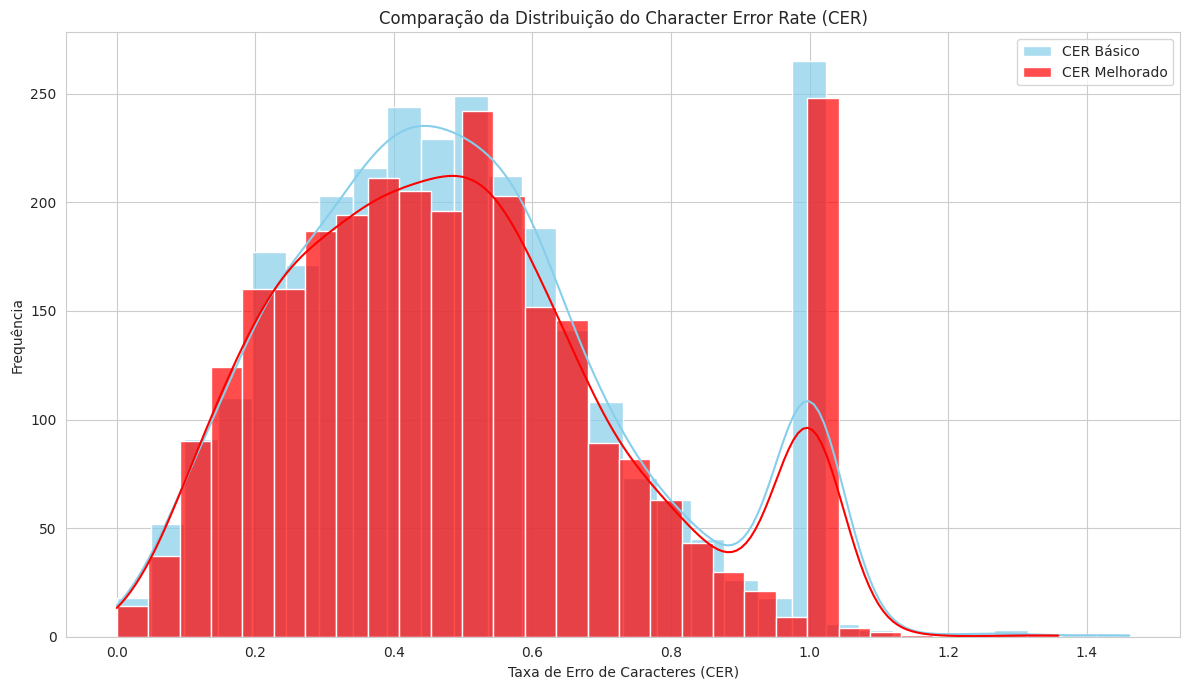

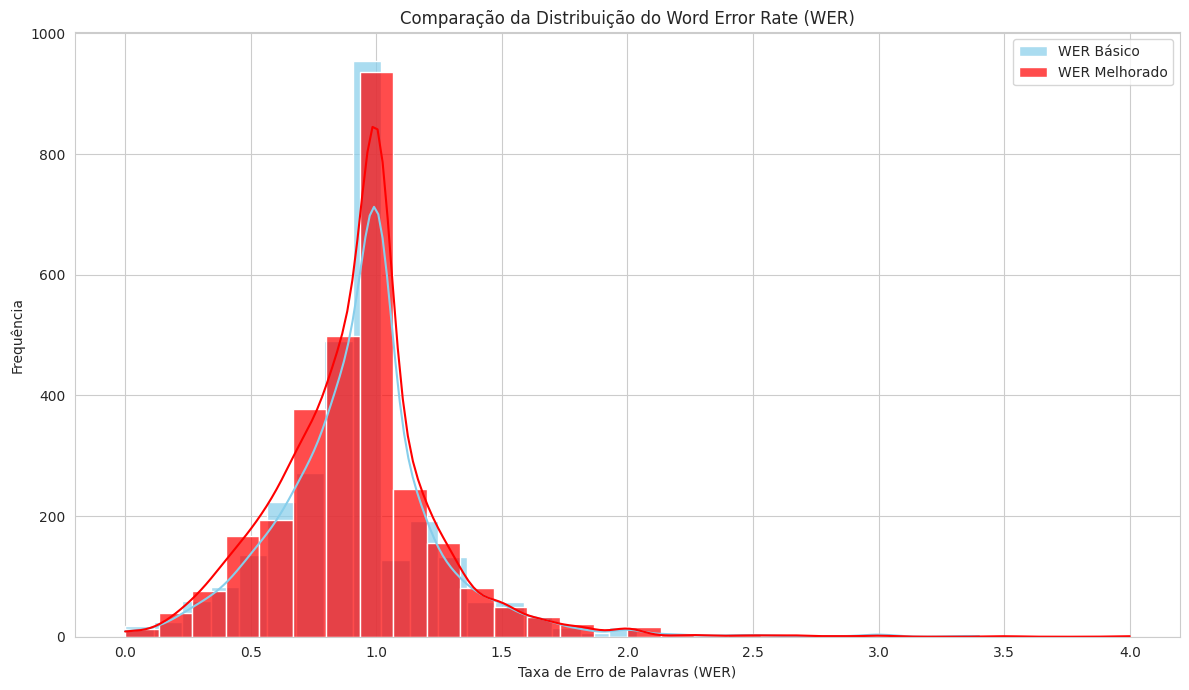

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Criar e exibir histogramas comparativos para CER
plt.figure(figsize=(12, 7))
sns.histplot(df_dados_iam['cer'], bins=30, kde=True, color='skyblue', label='CER Básico', alpha=0.7)
sns.histplot(df_dados_iam['cer_melhorado'], bins=30, kde=True, color='red', label='CER Melhorado', alpha=0.7)
plt.title('Comparação da Distribuição do Character Error Rate (CER)')
plt.xlabel('Taxa de Erro de Caracteres (CER)')
plt.ylabel('Frequência')
plt.legend()
plt.tight_layout()
plt.show()

# Criar e exibir histogramas comparativos para WER
plt.figure(figsize=(12, 7))
sns.histplot(df_dados_iam['wer'], bins=30, kde=True, color='skyblue', label='WER Básico', alpha=0.7)
sns.histplot(df_dados_iam['wer_melhorado'], bins=30, kde=True, color='red', label='WER Melhorado', alpha=0.7)
plt.title('Comparação da Distribuição do Word Error Rate (WER)')
plt.xlabel('Taxa de Erro de Palavras (WER)')
plt.ylabel('Frequência')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd # Importar caso o DataFrame não esteja acessível diretamente (embora já carregado) ou para boas práticas.

# 4. Identificar e imprimir a entrada com o menor CER melhorado (melhor desempenho da versão melhorada)
melhor_ocr_melhorado = df_dados_iam.loc[df_dados_iam['cer_melhorado'].idxmin()]
print("\n--- Melhor Desempenho de OCR (Melhorado - Menor CER) ---")
print(f"Caminho da Imagem: {melhor_ocr_melhorado['caminho_imagem']}")
print(f"Texto Original: {melhor_ocr_melhorado['texto_original']}")
print(f"Texto OCR Melhorado: {melhor_ocr_melhorado['texto_ocr_melhorado']}")
print(f"CER Melhorado: {melhor_ocr_melhorado['cer_melhorado']:.4f}")
print(f"WER Melhorado: {melhor_ocr_melhorado['wer_melhorado']:.4f}")

# 5. Identificar e imprimir a entrada com o maior CER melhorado (pior desempenho da versão melhorada)
pior_ocr_melhorado = df_dados_iam.loc[df_dados_iam['cer_melhorado'].idxmax()]
print("\n--- Pior Desempenho de OCR (Melhorado - Maior CER) ---")
print(f"Caminho da Imagem: {pior_ocr_melhorado['caminho_imagem']}")
print(f"Texto Original: {pior_ocr_melhorado['texto_original']}")
print(f"Texto OCR Melhorado: {pior_ocr_melhorado['texto_ocr_melhorado']}")
print(f"CER Melhorado: {pior_ocr_melhorado['cer_melhorado']:.4f}")
print(f"WER Melhorado: {pior_ocr_melhorado['wer_melhorado']:.4f}")


--- Melhor Desempenho de OCR (Melhorado - Menor CER) ---
Caminho da Imagem: /root/.cache/kagglehub/datasets/changheonkim/iam-trocr/versions/1/IAM/image/f04-079-02.jpg
Texto Original: occurred before her death was ensured by some
Texto OCR Melhorado: occurred before her death was ensured by some
CER Melhorado: 0.0000
WER Melhorado: 0.0000

--- Pior Desempenho de OCR (Melhorado - Maior CER) ---
Caminho da Imagem: /root/.cache/kagglehub/datasets/changheonkim/iam-trocr/versions/1/IAM/image/g01-025-06.jpg
Texto Original: story of the experiments and expedients
Texto OCR Melhorado: ts
, Bh
As
pe

2x

A

an

nts

2

yA

LV i

* p

<&

the

of

Stovy
CER Melhorado: 1.3590
WER Melhorado: 2.6667


## Final Task

Apresentar um resumo comparativo detalhado, destacando as melhorias ou regressões no desempenho do OCR obtidas com a nova função de pré-processamento, e as conclusões gerais.


## Resumo e Conclusões Finais

### Principais Descobertas da Análise de Dados

*   **Melhoria Geral no Desempenho**: A nova função de pré-processamento resultou em melhorias marginais, mas consistentes, na acurácia do OCR. A média da Taxa de Erro de Caracteres (CER) diminuiu ligeiramente de 0.5028 (básico) para 0.4944 (melhorado), e a média da Taxa de Erro de Palavras (WER) também teve uma pequena redução de 0.9352 (básico) para 0.9210 (melhorado).
*   **Variabilidade Reduzida**: O desvio padrão para o CER diminuiu de 0.2503 (básico) para 0.2489 (melhorado), e para o WER, reduziu de 0.3271 (básico) para 0.3224 (melhorado). Isso indica um desempenho ligeiramente mais consistente com a pipeline melhorada.
*   **Amplitude dos Erros**: Embora o CER máximo para a versão melhorada tenha sido menor (1.3590) em comparação com a básica (1.4615), o WER máximo para a versão melhorada foi ligeiramente maior (4.0) do que o da básica (3.4). Isso sugere que, para alguns casos específicos, o pré-processamento melhorado pode levar a erros de nível de palavra maiores.
*   **Exemplo de Melhor Desempenho**: O OCR melhorado alcançou transcrição perfeita (CER: 0.0000, WER: 0.0000) para a imagem `f04-079-02.jpg`, extraindo com precisão "occurred before her death was ensured by some".
*   **Exemplo de Pior Desempenho**: O OCR melhorado ainda teve dificuldades significativas com certas imagens, como `g01-025-06.jpg`, que apresentou o maior CER de 1.3590 e um WER de 2.6667. Para esta imagem, o texto original "story of the experiments and expedients" foi muito distorcido em uma saída como "ts\n, Bh\nAs\npe\n\n2x\n\nA\n\nan\n\nants\n\n2\n\nyA\n\nLV i\n\n\* p\n\n<&\n\nthe\n\nof\n\nStovy".

### Considerações Finais e Próximos Passos

*   As melhorias no pré-processamento trouxeram ganhos pequenos, mas positivos, em todo o conjunto de dados. Futuras iterações poderiam explorar técnicas mais avançadas (por exemplo, binarização adaptativa, correção de inclinação) ou pré-processamento baseado em aprendizado de máquina para alcançar melhorias mais substanciais.
*   É crucial investigar as características específicas das imagens onde o desempenho do OCR permanece insatisfatório (por exemplo, `g01-025-06.jpg`). Esta análise pode revelar as limitações da pipeline de pré-processamento atual ou do próprio modelo Tesseract ao lidar com variações extremas na caligrafia, qualidade da imagem ou layout.